<a href="https://colab.research.google.com/github/Dnyamwamu/neural_nets/blob/main/Notebooks/Chap04/4_2_Clipping_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4.2 -- Clipping functions

The purpose of this notebook is to understand how a neural network with two hidden layers build more complicated functions by clipping and recombining the representations at the intermediate hidden variables.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions

In [1]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [2]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
import numpy as np

def shallow_1_1_3_3(x, activation_fn, phi, psi, theta):
    """
    Deep network: 1 input, 1 output, 2 hidden layers, 3 hidden units each.

    phi: weights from layer 2 -> output, shape (4,)  # phi[0] = bias
    psi: weights from layer 1 -> layer 2, shape (3,4) # psi[i,0] = bias for unit i in layer2
    theta: weights from input -> layer1, shape (3,2)  # theta[i,0] = bias, theta[i,1] = weight for unit i
    """

    # --- Layer 1 preactivations ---
    layer1_pre = np.zeros((3, x.size))
    for i in range(3):
        layer1_pre[i] = theta[i,0] + theta[i,1] * x  # bias + weight * input

    # --- Layer 1 activations ---
    h = np.zeros_like(layer1_pre)
    for i in range(3):
        h[i] = activation_fn(layer1_pre[i])

    # --- Layer 2 preactivations ---
    layer2_pre = np.zeros((3, x.size))
    for j in range(3):
        layer2_pre[j] = psi[j,0]  # bias
        for i in range(3):
            layer2_pre[j] += psi[j,i+1] * h[i]  # weighted sum of layer1 activations

    # --- Layer 2 activations ---
    h_prime = np.zeros_like(layer2_pre)
    for j in range(3):
        h_prime[j] = activation_fn(layer2_pre[j])

    # --- Weighted outputs ---
    w_h_prime = np.zeros_like(h_prime)
    for j in range(3):
        w_h_prime[j] = phi[j+1] * h_prime[j]

    # --- Final output ---
    y = phi[0] + np.sum(w_h_prime, axis=0)

    # Return all intermediate values for plotting/debugging
    return y, layer2_pre[0], layer2_pre[1], layer2_pre[2], h_prime[0], h_prime[1], h_prime[2], w_h_prime[0], w_h_prime[1], w_h_prime[2]

In [4]:
# # Plot two layer neural network as in figure 4.5
def plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime):

    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,layer2_pre_1,'r-'); ax[0,0].set_ylabel(r'$\psi_{10}+\psi_{11}h_{1}+\psi_{12}h_{2}+\psi_{13}h_3$')
    ax[0,1].plot(x,layer2_pre_2,'b-'); ax[0,1].set_ylabel(r'$\psi_{20}+\psi_{21}h_{1}+\psi_{22}h_{2}+\psi_{23}h_3$')
    ax[0,2].plot(x,layer2_pre_3,'g-'); ax[0,2].set_ylabel(r'$\psi_{30}+\psi_{31}h_{1}+\psi_{32}h_{2}+\psi_{33}h_3$')
    ax[1,0].plot(x,h1_prime,'r-'); ax[1,0].set_ylabel(r"$h_{1}^{'}$")
    ax[1,1].plot(x,h2_prime,'b-'); ax[1,1].set_ylabel(r"$h_{2}^{'}$")
    ax[1,2].plot(x,h3_prime,'g-'); ax[1,2].set_ylabel(r"$h_{3}^{'}$")
    ax[2,0].plot(x,phi1_h1_prime,'r-'); ax[2,0].set_ylabel(r"$\phi_1 h_{1}^{'}$")
    ax[2,1].plot(x,phi2_h2_prime,'b-'); ax[2,1].set_ylabel(r"$\phi_2 h_{2}^{'}$")
    ax[2,2].plot(x,phi3_h3_prime,'g-'); ax[2,2].set_ylabel(r"$\phi_3 h_{3}^{'}$")

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel(r'Input, $x$');
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x,y)
    ax.set_xlabel(r'Input, $x$'); ax.set_ylabel(r'Output, $y$')
    ax.set_xlim([0,1]);ax.set_ylim([-1,1])
    ax.set_aspect(0.5)
    plt.show()

Now let's define the parameters and visualize the network

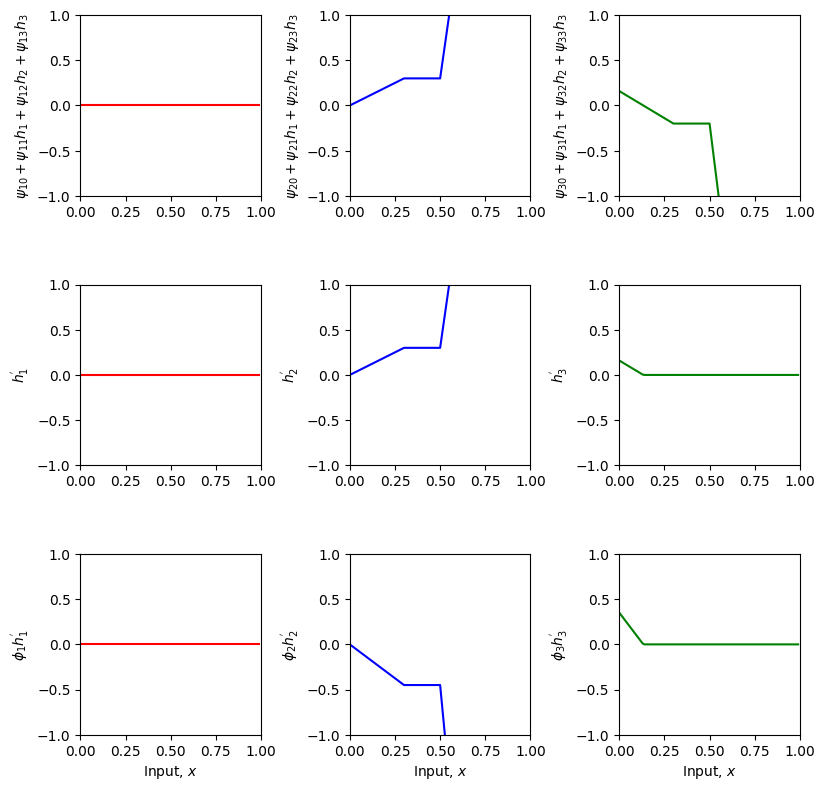

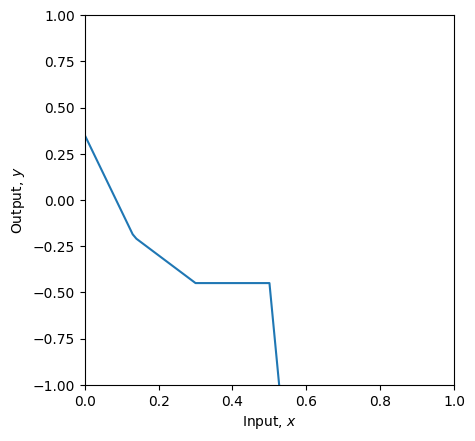

In [5]:
# Define parameters (note first dimension of theta and psi is padded to make indices match
# notation in book)
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65
psi[1,0] = 0.3;  psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0
psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2

# Define a range of input values
x = np.arange(0,1,0.01)

# Run the neural network
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# And then plot it
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)

To do:  To test your understanding of this, consider:

1.   What would happen if we increase $\psi_{1,0}$?
2.   What would happen if we multiplied $\psi_{2,0}, \psi_{2,1}, \psi_{2,2},  \psi_{2,3}$ by -1?
3.  What would happen if set $\phi_{3}$ to -1?

You can rerun the code to see if you were correct.



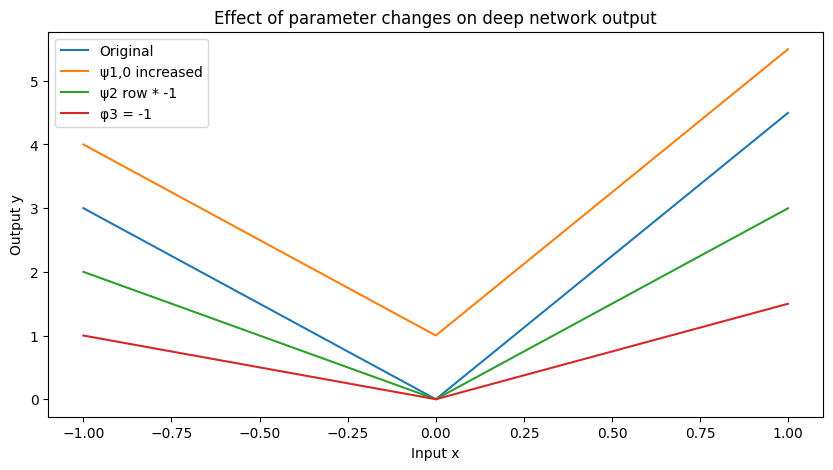

In [6]:
# Example parameters
phi = np.array([0.0, 1.0, 1.0, 1.0])       # φ0, φ1, φ2, φ3
psi = np.array([[0.0, 1.0, 1.0, 1.0],      # ψ1,0..ψ1,3
                [0.0, 1.0, 1.0, 1.0],
                [0.0, 1.0, 1.0, 1.0]])     # ψ3,0..ψ3,3
theta = np.array([[0.0, 1.0],
                  [0.0, -1.0],
                  [0.0, 0.5]])

x = np.arange(-1,1,0.001)

# Original network output
y, *_ = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# Increase ψ1,0
psi_new = psi.copy()
psi_new[0,0] += 1.0
y_psi1_bias = shallow_1_1_3_3(x, ReLU, phi, psi_new, theta)[0]

# Multiply ψ2 row by -1
psi_new2 = psi.copy()
psi_new2[1,:] *= -1
y_psi2_flip = shallow_1_1_3_3(x, ReLU, phi, psi_new2, theta)[0]

# Set φ3 = -1
phi_new = phi.copy()
phi_new[3] = -1
y_phi3_neg = shallow_1_1_3_3(x, ReLU, phi_new, psi, theta)[0]

# Plot all
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(x, y, label='Original')
plt.plot(x, y_psi1_bias, label='ψ1,0 increased')
plt.plot(x, y_psi2_flip, label='ψ2 row * -1')
plt.plot(x, y_phi3_neg, label='φ3 = -1')
plt.legend()
plt.xlabel('Input x')
plt.ylabel('Output y')
plt.title('Effect of parameter changes on deep network output')
plt.show()